In [1]:
ablation_results = []

In [2]:
import pickle
from pathlib import Path

project_root = Path.cwd().resolve()
for folder in [project_root, *project_root.parents]:
    if (folder / "models" / "phase1_outputs.pkl").exists():
        project_root = folder
        models_dir = folder / "models"
        break
else:
    raise FileNotFoundError("Could not locate the models directory containing phase1_outputs.pkl.")

with open(models_dir / "phase1_outputs.pkl", "rb") as f:
    data = pickle.load(f)

G        = data["G"]
df_full  = data["df_full"]
df_edges = data["df_edges"]
df_rank  = data["df_rank"]
node_list = data["node_list"]
node_idx  = data["node_idx"]

print("Loaded:", len(node_list), "tanks,", G.number_of_edges(), "edges")


Loaded: 32 tanks, 32 edges


In [3]:
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
import numpy as np

# Node feature columns to use
feature_cols = [
    "elevation_m", "catchment_area_km2",
    "num_catchment_basins"
]

# Build aligned feature matrix (in same order as G.nodes())
node_list = list(G.nodes())
node_idx = {n: i for i, n in enumerate(node_list)}
df_aligned = df_full.set_index("tank_name").reindex(node_list)
X_raw = df_aligned[feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_tensor = torch.tensor(X_scaled, dtype=torch.float)

# Build edge index
edge_src = [node_idx[r.source_tank] for _, r in df_edges.iterrows()]
edge_tgt = [node_idx[r.target_tank] for _, r in df_edges.iterrows()]
edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)

# Edge features
edge_attr = torch.tensor(
    df_edges[["elev_diff_m","slope_m/m"]].values,
    dtype=torch.float)

data = Data(x=X_tensor, edge_index=edge_index, edge_attr=edge_attr)
print(data)

Data(x=[32, 3], edge_index=[2, 32], edge_attr=[32, 2])


In [4]:
import torch.nn as nn
from torch_geometric.nn import GATConv

class CascadeGAT(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, heads=2):
        super().__init__()
        self.conv1 = GATConv(in_ch, hidden, heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden*heads, out_ch, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model = CascadeGAT(in_ch=3, hidden=16, out_ch=8)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

CascadeGAT(
  (conv1): GATConv(3, 16, heads=2)
  (conv2): GATConv(32, 8, heads=1)
)
Parameters: 472


In [6]:
# ── GATv2 variant — smallest possible diff from CascadeGAT ──
# Only change: GATConv -> GATv2Conv. Everything else identical.
from torch_geometric.nn import GATv2Conv

class CascadeGATv2(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, heads=2):
        super().__init__()
        self.conv1 = GATv2Conv(in_ch, hidden, heads=heads, dropout=0.2)
        self.conv2 = GATv2Conv(hidden*heads, out_ch, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model_v2 = CascadeGATv2(in_ch=3, hidden=16, out_ch=8)
print(model_v2)
print("Parameters:", sum(p.numel() for p in model_v2.parameters()))

CascadeGATv2(
  (conv1): GATv2Conv(3, 16, heads=2)
  (conv2): GATv2Conv(32, 8, heads=1)
)
Parameters: 864


In [7]:
from torch_geometric.utils import negative_sampling
import torch.nn.functional as F

# ── Train GATv2 (same procedure as GATv1, cell 5) ──
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.01)

def train_v2(epochs=200):
    model_v2.train()
    losses = []
    for ep in range(epochs):
        optimizer_v2.zero_grad()
        z = model_v2(data.x, data.edge_index)

        pos_src = data.edge_index[0]
        pos_tgt = data.edge_index[1]
        pos_score = (z[pos_src] * z[pos_tgt]).sum(dim=1)

        neg_idx = negative_sampling(data.edge_index, num_nodes=32)
        neg_src = neg_idx[0]; neg_tgt = neg_idx[1]
        neg_score = (z[neg_src] * z[neg_tgt]).sum(dim=1)

        # Numerically stable — avoids log(0) = -inf -> nan weights
        loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()

        loss.backward()
        optimizer_v2.step()

        if ep % 20 == 0:
            print(f"Epoch {ep:3d} | Loss: {loss.item():.4f}")
        losses.append(loss.item())
    return losses

losses_v2 = train_v2(200)

Epoch   0 | Loss: 2.2100
Epoch  20 | Loss: 1.2474
Epoch  40 | Loss: 1.2104
Epoch  60 | Loss: 1.1030
Epoch  80 | Loss: 1.1859
Epoch 100 | Loss: 1.0353
Epoch 120 | Loss: 1.1474
Epoch 140 | Loss: 1.0093
Epoch 160 | Loss: 1.2159
Epoch 180 | Loss: 1.3650


In [9]:
from torch_geometric.utils import negative_sampling
import torch.nn.functional as F

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train(epochs=200):
    model.train()
    losses = []
    for ep in range(epochs):
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)

        # Positive pairs: connected tanks should be similar
        pos_src = data.edge_index[0]
        pos_tgt = data.edge_index[1]
        pos_score = (z[pos_src] * z[pos_tgt]).sum(dim=1)

        # Negative pairs: unconnected tanks should differ
        neg_idx = negative_sampling(data.edge_index, num_nodes=32)
        neg_src = neg_idx[0]; neg_tgt = neg_idx[1]
        neg_score = (z[neg_src] * z[neg_tgt]).sum(dim=1)

        # Numerically stable — avoids log(0) = -inf -> nan weights
        loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()

        loss.backward()
        optimizer.step()

        if ep % 20 == 0:
            print(f"Epoch {ep:3d} | Loss: {loss.item():.4f}")
        losses.append(loss.item())
    return losses

losses = train(200)

Epoch   0 | Loss: 0.9917
Epoch  20 | Loss: 1.0960
Epoch  40 | Loss: 1.1106
Epoch  60 | Loss: 1.1028
Epoch  80 | Loss: 0.9213
Epoch 100 | Loss: 0.9548
Epoch 120 | Loss: 1.1075
Epoch 140 | Loss: 1.4117
Epoch 160 | Loss: 1.0589
Epoch 180 | Loss: 1.0400


In [10]:
model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index)

embeddings = z.detach().cpu().numpy()
gnn_importance = np.linalg.norm(embeddings, axis=1)

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
gnn_sensitivity = (embeddings @ embeddings.T) / (norms * norms.T + 1e-9)

df_rank = df_rank.copy()
df_rank["gnn_importance"] = [gnn_importance[node_idx[n]] for n in df_rank["tank"]]
df_rank = df_rank.sort_values("gnn_importance", ascending=False)

# Save model weights separately
models_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), models_dir / "cascade_gat_weights.pth")

with open(models_dir / "phase2_outputs.pkl", "wb") as f:
    pickle.dump({
        "embeddings":      embeddings,
        "gnn_importance":  gnn_importance,
        "gnn_sensitivity": gnn_sensitivity,
        "df_rank":         df_rank,
        "node_list":       node_list,
        "node_idx":        node_idx
    }, f)

print("Phase 2 outputs saved!")
print(f"Model weights saved to {models_dir / 'cascade_gat_weights.pth'}")


Phase 2 outputs saved!
Model weights saved to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\models\cascade_gat_weights.pth


In [11]:
# ── GAT (v1) + edge features ──
# Same GATConv as cell 2's baseline, but now edge_dim=2 and edge_attr flows through forward()
from torch_geometric.nn import GATConv

class CascadeGATEdge(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, edge_dim, heads=2):
        super().__init__()
        self.conv1 = GATConv(in_ch, hidden, heads=heads, dropout=0.2, edge_dim=edge_dim)
        self.conv2 = GATConv(hidden*heads, out_ch, heads=1, concat=False, edge_dim=edge_dim)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr).relu()
        x = self.conv2(x, edge_index, edge_attr)
        return x

model_edge = CascadeGATEdge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
print(model_edge)
print("Parameters:", sum(p.numel() for p in model_edge.parameters()))

CascadeGATEdge(
  (conv1): GATConv(3, 16, heads=2)
  (conv2): GATConv(32, 8, heads=1)
)
Parameters: 592


In [12]:
import torch.nn.functional as F

optimizer_edge = torch.optim.Adam(model_edge.parameters(), lr=0.01)

def train_edge(epochs=200):
    model_edge.train()
    losses = []
    for ep in range(epochs):
        optimizer_edge.zero_grad()
        z = model_edge(data.x, data.edge_index, data.edge_attr)

        pos_src = data.edge_index[0]
        pos_tgt = data.edge_index[1]
        pos_score = (z[pos_src] * z[pos_tgt]).sum(dim=1)

        neg_idx = negative_sampling(data.edge_index, num_nodes=32)
        neg_src = neg_idx[0]; neg_tgt = neg_idx[1]
        neg_score = (z[neg_src] * z[neg_tgt]).sum(dim=1)

        # Numerically stable — avoids log(0) = -inf -> nan weights
        loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()

        loss.backward()
        optimizer_edge.step()

        if ep % 20 == 0:
            print(f"Epoch {ep:3d} | Loss: {loss.item():.4f}")
        losses.append(loss.item())
    return losses

losses_edge = train_edge(200)

Epoch   0 | Loss: 1.3544
Epoch  20 | Loss: 1.2384
Epoch  40 | Loss: 1.1089
Epoch  60 | Loss: 1.0522
Epoch  80 | Loss: 1.0961
Epoch 100 | Loss: 0.9497
Epoch 120 | Loss: 1.0572
Epoch 140 | Loss: 1.0006
Epoch 160 | Loss: 1.0070
Epoch 180 | Loss: 1.1354


  METRIC 1: Link Prediction AUC

  Link Prediction AUC : 0.6735
  Test edges (pos)    : 7
  Test edges (neg)    : 7

  ~ FAIR  — model has partial learning (AUC 0.65–0.80)

  METRIC 2: Spearman Rank Correlation
  GNN importance vs Classical importance

  Spearman ρ  : 0.4488
  p-value     : 0.0100

  ~ MODERATE agreement — GNN partially agrees with classical
    GNN found some additional patterns classical missed

  Interpretation: GNN and classical methods have moderate rank agreement (ρ=0.449)

  METRIC 3: Stability Analysis (10 random seeds)

  Tank ranking stability across 10 runs:

  Tank                                 Mean Rank    Std Dev    Stability
  -------------------------------------------------------------------
  Nachchaduwa Wewa                           2.6       1.56      STABLE
  Hammillakulama Wewa                        2.7       1.42      STABLE
  Galwaduwawa Wewa                           4.7       2.72    MODERATE
  Manakkulama Wewa                           5.

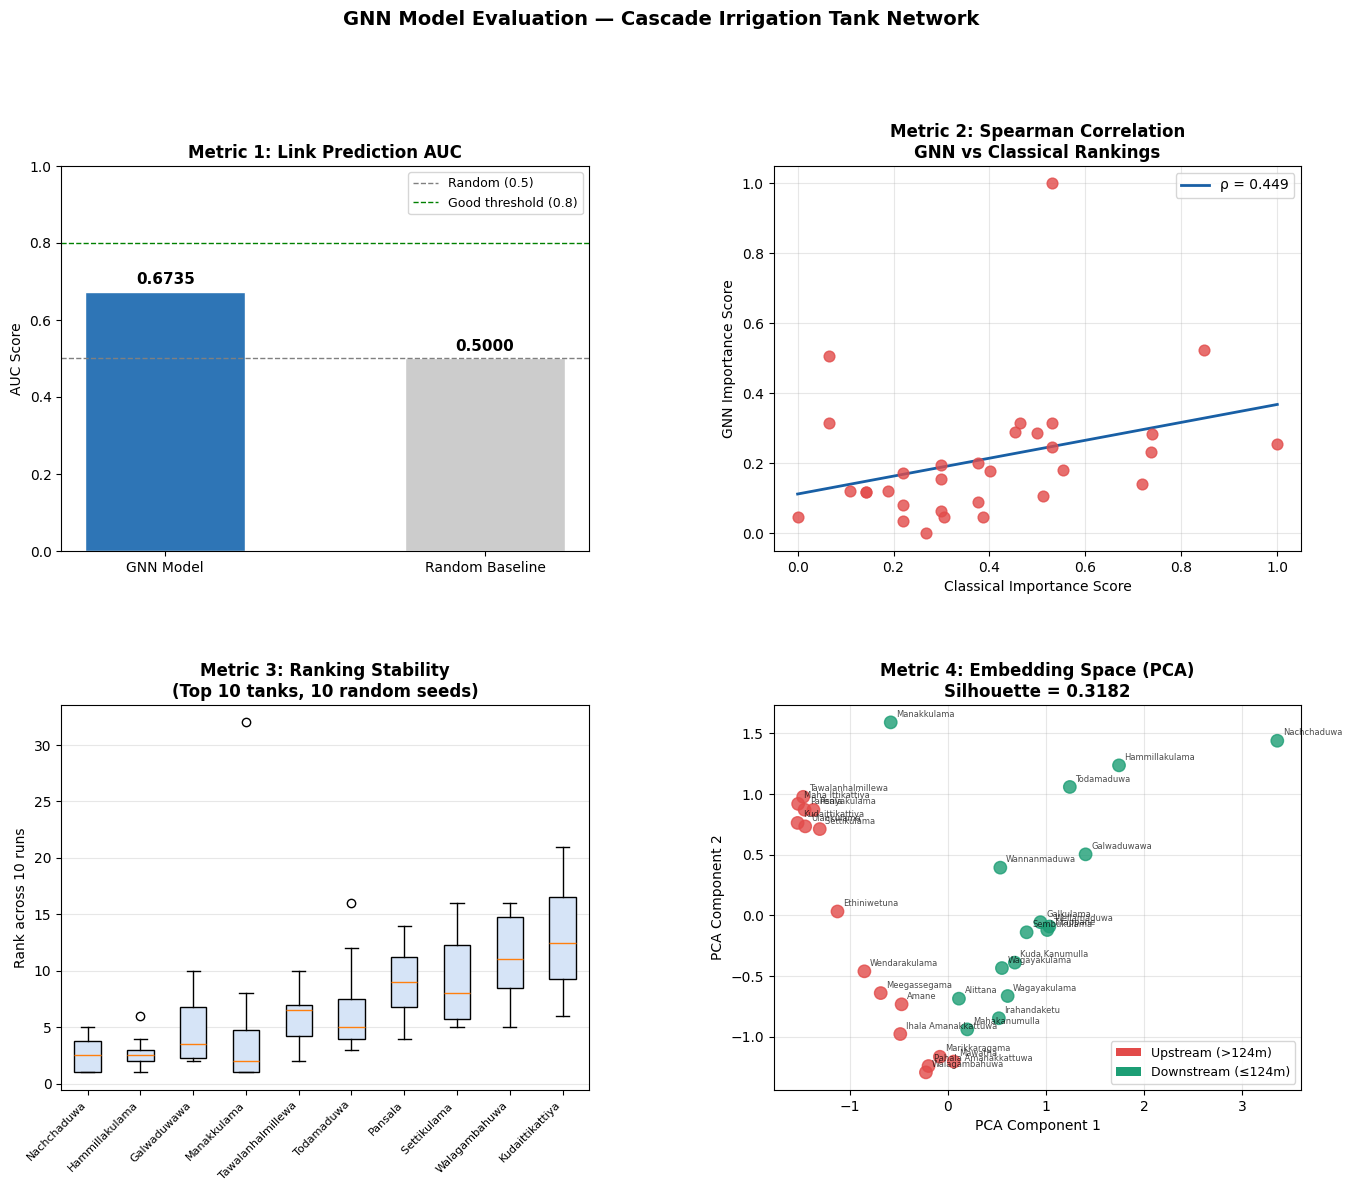

Saved gnn_evaluation_plots.png


In [13]:
# ════════════════════════════════════════════════════════════════
# GNN EVALUATION METRICS
# 1. Link Prediction AUC  — did the GNN learn the graph structure?
# 2. Spearman Correlation — does GNN agree with classical metrics?
# 3. Stability Analysis   — are results consistent across 10 runs?
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
from pathlib import Path

output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

# ── METRIC 1: Link Prediction AUC ────────────────────────────────
print("=" * 55)
print("  METRIC 1: Link Prediction AUC")
print("=" * 55)

all_edges = data.edge_index.T.numpy()
n_nodes   = 32

from torch_geometric.utils import negative_sampling
neg_edges = negative_sampling(
    data.edge_index,
    num_nodes=n_nodes,
    num_neg_samples=len(all_edges)
).T.numpy()

pos_train, pos_test = train_test_split(all_edges, test_size=0.2, random_state=42)
neg_train, neg_test = train_test_split(neg_edges, test_size=0.2, random_state=42)

train_edge_index = torch.tensor(pos_train.T, dtype=torch.long)

model_eval = CascadeGAT(in_ch=3, hidden=16, out_ch=8)
optimizer_eval = torch.optim.Adam(model_eval.parameters(), lr=0.01)

model_eval.train()
for ep in range(300):
    optimizer_eval.zero_grad()
    z = model_eval(data.x, train_edge_index)

    ps = torch.tensor(pos_train[:, 0])
    pt = torch.tensor(pos_train[:, 1])
    pos_score = (z[ps] * z[pt]).sum(dim=1)

    neg_t = torch.tensor(neg_train)
    ns = neg_t[:, 0]; nt = neg_t[:, 1]
    neg_score = (z[ns] * z[nt]).sum(dim=1)

    # FIXED: numerically stable, avoids log(0) = -inf -> nan weights
    loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()
    loss.backward()
    optimizer_eval.step()

model_eval.eval()
with torch.no_grad():
    z_eval = model_eval(data.x, train_edge_index)

def score_pairs(z, pairs):
    src = torch.tensor(pairs[:, 0])
    tgt = torch.tensor(pairs[:, 1])
    return torch.sigmoid((z[src] * z[tgt]).sum(dim=1)).numpy()

pos_scores = score_pairs(z_eval, pos_test)
neg_scores = score_pairs(z_eval, neg_test)

y_true  = np.array([1]*len(pos_test) + [0]*len(neg_test))
y_score = np.concatenate([pos_scores, neg_scores])

auc = roc_auc_score(y_true, y_score)

print(f"\n  Link Prediction AUC : {auc:.4f}")
print(f"  Test edges (pos)    : {len(pos_test)}")
print(f"  Test edges (neg)    : {len(neg_test)}")
print()
if auc >= 0.80:
    print("  ✓ GOOD  — model learned cascade structure well (AUC ≥ 0.80)")
elif auc >= 0.65:
    print("  ~ FAIR  — model has partial learning (AUC 0.65–0.80)")
else:
    print("  ✗ POOR  — model struggled (AUC < 0.65) — consider more epochs")

# ── METRIC 2: Spearman Correlation ───────────────────────────────
print()
print("=" * 55)
print("  METRIC 2: Spearman Rank Correlation")
print("  GNN importance vs Classical importance")
print("=" * 55)

df_eval = df_rank.copy()

def norm01(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

classical_scores = norm01(df_eval["importance_score"]).values
gnn_scores       = norm01(df_eval["gnn_importance"]).values

corr, pval = spearmanr(classical_scores, gnn_scores)

print(f"\n  Spearman ρ  : {corr:.4f}")
print(f"  p-value     : {pval:.4f}")
print()
if corr >= 0.7:
    print("  ✓ HIGH agreement — GNN confirms classical rankings")
    print("    Both methods consistently identify the same critical tanks")
elif corr >= 0.4:
    print("  ~ MODERATE agreement — GNN partially agrees with classical")
    print("    GNN found some additional patterns classical missed")
else:
    print("  ✗ LOW agreement — GNN rankings differ significantly")
    print("    GNN captured very different influence patterns — investigate")

print(f"\n  Interpretation: GNN and classical methods have "
      f"{'strong' if corr>=0.7 else 'moderate' if corr>=0.4 else 'weak'} "
      f"rank agreement (ρ={corr:.3f})")

# ── METRIC 3: Stability Analysis (10 runs) ───────────────────────
print()
print("=" * 55)
print("  METRIC 3: Stability Analysis (10 random seeds)")
print("=" * 55)

N_RUNS   = 10
all_rankings = []

for seed in range(N_RUNS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    m = CascadeGAT(in_ch=3, hidden=16, out_ch=8)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)

    m.train()
    for ep in range(200):
        opt.zero_grad()
        z = m(data.x, data.edge_index)
        ps = data.edge_index[0]; pt = data.edge_index[1]
        pos_s = (z[ps] * z[pt]).sum(dim=1)
        ni = negative_sampling(data.edge_index, num_nodes=32)
        neg_s = (z[ni[0]] * z[ni[1]]).sum(dim=1)
        # FIXED: numerically stable, avoids log(0) = -inf -> nan weights
        loss = -F.logsigmoid(pos_s).mean() - F.logsigmoid(-neg_s).mean()
        loss.backward()
        opt.step()

    m.eval()
    with torch.no_grad():
        emb = m(data.x, data.edge_index).numpy()

    importance = np.linalg.norm(emb, axis=1)
    ranked = pd.Series(importance, index=node_list).rank(ascending=False)
    all_rankings.append(ranked)

df_stability = pd.DataFrame(all_rankings).T
df_stability.columns = [f"run_{i}" for i in range(N_RUNS)]
df_stability["mean_rank"] = df_stability.mean(axis=1)
df_stability["std_rank"]  = df_stability.std(axis=1)
df_stability["cv"]        = df_stability["std_rank"] / df_stability["mean_rank"]
df_stability = df_stability.sort_values("mean_rank")

print(f"\n  Tank ranking stability across {N_RUNS} runs:\n")
print(f"  {'Tank':<35} {'Mean Rank':>10} {'Std Dev':>10} {'Stability':>12}")
print("  " + "-"*67)
for tank, row in df_stability.iterrows():
    stability = "STABLE" if row["std_rank"] < 2 else \
                "MODERATE" if row["std_rank"] < 4 else "UNSTABLE"
    print(f"  {tank:<35} {row['mean_rank']:>10.1f} "
          f"{row['std_rank']:>10.2f}  {stability:>10}")

mean_std = df_stability["std_rank"].mean()
print(f"\n  Average rank std deviation : {mean_std:.2f}")
print(f"  {'✓ STABLE' if mean_std < 2 else '~ MODERATE' if mean_std < 4 else '✗ UNSTABLE'} "
      f"— model {'produces consistent rankings' if mean_std < 2 else 'has some variation in rankings'}")

# ── METRIC 4: Embedding Separation (bonus) ───────────────────────
print()
print("=" * 55)
print("  METRIC 4: Upstream vs Downstream Separation")
print("  Do embeddings separate high/low elevation tanks?")
print("=" * 55)

from sklearn.metrics import silhouette_score

elevations = df_full.set_index("tank_name").reindex(node_list)["elevation_m"].values
median_elev = np.median(elevations)
elev_labels = (elevations > median_elev).astype(int)

model.eval()
with torch.no_grad():
    final_emb = model(data.x, data.edge_index).numpy()

sil_score = silhouette_score(final_emb, elev_labels)
print(f"\n  Silhouette Score (upstream vs downstream) : {sil_score:.4f}")
print(f"  Median elevation split : {median_elev:.0f}m")
print(f"  Upstream tanks  (>{median_elev:.0f}m) : {elev_labels.sum()}")
print(f"  Downstream tanks (<={median_elev:.0f}m) : {(1-elev_labels).sum()}")
print()
if sil_score > 0.3:
    print("  ✓ GOOD — GNN embeddings clearly separate upstream/downstream tanks")
elif sil_score > 0.1:
    print("  ~ FAIR — some separation exists in embedding space")
else:
    print("  ~ LOW  — embeddings don't strongly separate by elevation")
    print("    This may mean the GNN learned more complex patterns than elevation alone")

# ── SUMMARY TABLE ─────────────────────────────────────────────────
print()
print("=" * 55)
print("  EVALUATION SUMMARY")
print("=" * 55)
print(f"  Metric 1 — Link Prediction AUC    : {auc:.4f}")
print(f"  Metric 2 — Spearman Correlation   : {corr:.4f}  (p={pval:.4f})")
print(f"  Metric 3 — Avg Rank Std Deviation : {mean_std:.4f}")
print(f"  Metric 4 — Silhouette Score       : {sil_score:.4f}")
print()

df_metrics = pd.DataFrame([{
    "metric":      "Link Prediction AUC",
    "value":       round(auc, 4),
    "interpretation": "Model correctly predicts cascade connections (1.0=perfect, 0.5=random)"
},{
    "metric":      "Spearman Correlation (GNN vs Classical)",
    "value":       round(corr, 4),
    "interpretation": "Agreement between GNN and classical importance rankings"
},{
    "metric":      "Rank Stability (Avg Std Dev across 10 runs)",
    "value":       round(mean_std, 4),
    "interpretation": "Lower = more stable rankings (< 2.0 = good)"
},{
    "metric":      "Silhouette Score (upstream vs downstream)",
    "value":       round(sil_score, 4),
    "interpretation": "How well embeddings separate upstream/downstream tanks (>0.3 = good)"
}])

df_metrics.to_csv(output_dir / "gnn_evaluation_metrics.csv", index=False)
df_stability.to_csv(output_dir / "gnn_stability_analysis.csv")
print(f"  Saved gnn_evaluation_metrics.csv")
print(f"  Saved gnn_stability_analysis.csv")

# ── PLOT ALL METRICS ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(["GNN Model", "Random Baseline"],
               [auc, 0.5],
               color=["#2E75B6", "#CCCCCC"], width=0.5, edgecolor="white")
ax1.set_ylim(0, 1.0)
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random (0.5)")
ax1.axhline(0.8, color="green", linestyle="--", linewidth=1, label="Good threshold (0.8)")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.4f}", ha="center", fontsize=11, fontweight="bold")
ax1.set_title("Metric 1: Link Prediction AUC", fontweight="bold")
ax1.set_ylabel("AUC Score")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(classical_scores, gnn_scores, color="#E24B4A", s=60, alpha=0.8, zorder=3)
mfit, bfit = np.polyfit(classical_scores, gnn_scores, 1)
x_line = np.linspace(0, 1, 100)
ax2.plot(x_line, mfit*x_line + bfit, color="#185FA5", linewidth=2, label=f"ρ = {corr:.3f}")
ax2.set_xlabel("Classical Importance Score")
ax2.set_ylabel("GNN Importance Score")
ax2.set_title("Metric 2: Spearman Correlation\nGNN vs Classical Rankings", fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
top10 = df_stability.head(10).index.tolist()
stability_data = [df_stability.loc[t, [f"run_{i}" for i in range(N_RUNS)]].values
                  for t in top10]
bp = ax3.boxplot(stability_data, patch_artist=True, vert=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#D6E4F7")
ax3.set_xticks(range(1, len(top10)+1))
ax3.set_xticklabels([t.replace(" Wewa","") for t in top10],
                    rotation=45, ha="right", fontsize=8)
ax3.set_ylabel("Rank across 10 runs")
ax3.set_title("Metric 3: Ranking Stability\n(Top 10 tanks, 10 random seeds)", fontweight="bold")
ax3.grid(True, alpha=0.3, axis="y")

ax4 = fig.add_subplot(gs[1, 1])
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(final_emb)
colors_emb = ["#E24B4A" if l == 1 else "#1D9E75" for l in elev_labels]
ax4.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors_emb, s=80, alpha=0.8, zorder=3)
for idx, name in enumerate(node_list):
    ax4.annotate(name.replace(" Wewa",""),
                 (emb_2d[idx, 0], emb_2d[idx, 1]),
                 fontsize=6, alpha=0.7,
                 xytext=(4, 4), textcoords="offset points")
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#E24B4A", label=f"Upstream (>{median_elev:.0f}m)"),
                Patch(facecolor="#1D9E75", label=f"Downstream (≤{median_elev:.0f}m)")]
ax4.legend(handles=legend_elems, fontsize=9)
ax4.set_title(f"Metric 4: Embedding Space (PCA)\nSilhouette = {sil_score:.4f}", fontweight="bold")
ax4.set_xlabel("PCA Component 1")
ax4.set_ylabel("PCA Component 2")
ax4.grid(True, alpha=0.3)

fig.suptitle("GNN Model Evaluation — Cascade Irrigation Tank Network",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(output_dir / "gnn_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gnn_evaluation_plots.png")

In [14]:
# ── Evaluation: GAT + edge features ──
idx_train, idx_test = train_test_split(np.arange(len(all_edges)), test_size=0.2, random_state=42)
pos_train_ge, pos_test_ge = all_edges[idx_train], all_edges[idx_test]
train_edge_attr_ge = data.edge_attr[idx_train]
neg_train_ge, neg_test_ge = train_test_split(neg_edges, test_size=0.2, random_state=42)
train_edge_index_ge = torch.tensor(pos_train_ge.T, dtype=torch.long)

model_eval_edge = CascadeGATEdge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
optimizer_eval_edge = torch.optim.Adam(model_eval_edge.parameters(), lr=0.01)

model_eval_edge.train()
for ep in range(300):
    optimizer_eval_edge.zero_grad()
    z = model_eval_edge(data.x, train_edge_index_ge, train_edge_attr_ge)
    ps = torch.tensor(pos_train_ge[:, 0]); pt = torch.tensor(pos_train_ge[:, 1])
    pos_score = (z[ps] * z[pt]).sum(dim=1)
    neg_t = torch.tensor(neg_train_ge)
    ns = neg_t[:, 0]; nt = neg_t[:, 1]
    neg_score = (z[ns] * z[nt]).sum(dim=1)
    loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()
    loss.backward()
    optimizer_eval_edge.step()

model_eval_edge.eval()
with torch.no_grad():
    z_eval_edge = model_eval_edge(data.x, train_edge_index_ge, train_edge_attr_ge)

pos_scores = score_pairs(z_eval_edge, pos_test_ge)
neg_scores = score_pairs(z_eval_edge, neg_test_ge)
y_true  = np.array([1]*len(pos_test_ge) + [0]*len(neg_test_ge))
y_score = np.concatenate([pos_scores, neg_scores])
auc_edge = roc_auc_score(y_true, y_score)
print(f"AUC (GAT + edge features): {auc_edge:.4f}")

model_edge.eval()
with torch.no_grad():
    full_emb_edge = model_edge(data.x, data.edge_index, data.edge_attr).numpy()

gnn_importance_edge = np.linalg.norm(full_emb_edge, axis=1)
df_eval_edge = df_rank.copy()
df_eval_edge["gnn_importance_edge"] = [gnn_importance_edge[node_list.index(n)] for n in df_eval_edge["tank"]]

classical_scores_edge = norm01(df_eval_edge["importance_score"]).values
gnn_scores_edge = norm01(df_eval_edge["gnn_importance_edge"]).values
corr_edge, pval_edge = spearmanr(classical_scores_edge, gnn_scores_edge)
print(f"Spearman ρ (GAT + edge features): {corr_edge:.4f}")

all_rankings_edge = []
for seed in range(10):
    torch.manual_seed(seed); np.random.seed(seed)
    m = CascadeGATEdge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    m.train()
    for ep in range(200):
        opt.zero_grad()
        z = m(data.x, data.edge_index, data.edge_attr)
        ps = data.edge_index[0]; pt = data.edge_index[1]
        pos_s = (z[ps] * z[pt]).sum(dim=1)
        ni = negative_sampling(data.edge_index, num_nodes=32)
        neg_s = (z[ni[0]] * z[ni[1]]).sum(dim=1)
        loss = -F.logsigmoid(pos_s).mean() - F.logsigmoid(-neg_s).mean()
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        emb = m(data.x, data.edge_index, data.edge_attr).numpy()
    importance = np.linalg.norm(emb, axis=1)
    ranked = pd.Series(importance, index=node_list).rank(ascending=False)
    all_rankings_edge.append(ranked)

df_stability_edge = pd.DataFrame(all_rankings_edge).T
mean_std_edge = df_stability_edge.std(axis=1).mean()
print(f"Avg rank std dev (GAT + edge features): {mean_std_edge:.4f}")

sil_score_edge = silhouette_score(full_emb_edge, elev_labels)
print(f"Silhouette (GAT + edge features): {sil_score_edge:.4f}")

ablation_results.append({
    "model": "GAT", "edge_features": True,
    "auc": round(auc_edge, 4), "spearman": round(corr_edge, 4),
    "stability_std": round(mean_std_edge, 4), "silhouette": round(sil_score_edge, 4)
})

AUC (GAT + edge features): 0.5102
Spearman ρ (GAT + edge features): 0.2372
Avg rank std dev (GAT + edge features): 4.2113
Silhouette (GAT + edge features): 0.4077


In [15]:
# Persist stability results so later notebooks (e.g. phase3 visualization) don't need to retrain
with open(models_dir / "phase2_outputs.pkl", "rb") as f:
    p2_existing = pickle.load(f)

p2_existing["stability_std"] = df_stability.std(axis=1)   # per-tank rank std dev, indexed by tank name

with open(models_dir / "phase2_outputs.pkl", "wb") as f:
    pickle.dump(p2_existing, f)

print("Added stability_std to phase2_outputs.pkl")

Added stability_std to phase2_outputs.pkl


In [16]:
if "ablation_results" not in dir():
    ablation_results = []

ablation_results.append({
    "model": "GAT", "edge_features": False,
    "auc": round(auc, 4), "spearman": round(corr, 4),
    "stability_std": round(mean_std, 4), "silhouette": round(sil_score, 4)
})
pd.DataFrame(ablation_results)

,model,edge_features,auc,spearman,stability_std,silhouette
0,GAT,True,0.5102,0.2372,4.2113,0.4077
1,GAT,False,0.6735,0.4488,4.9573,0.3182


In [17]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

# ── Metric 1: AUC ──
pos_train, pos_test = train_test_split(all_edges, test_size=0.2, random_state=42)
neg_train, neg_test = train_test_split(neg_edges, test_size=0.2, random_state=42)
train_edge_index = torch.tensor(pos_train.T, dtype=torch.long)

model_eval_v2 = CascadeGATv2(in_ch=3, hidden=16, out_ch=8)
optimizer_eval_v2 = torch.optim.Adam(model_eval_v2.parameters(), lr=0.01)

model_eval_v2.train()
for ep in range(300):
    optimizer_eval_v2.zero_grad()
    z = model_eval_v2(data.x, train_edge_index)

    ps = torch.tensor(pos_train[:, 0]); pt = torch.tensor(pos_train[:, 1])
    pos_score = (z[ps] * z[pt]).sum(dim=1)
    neg_t = torch.tensor(neg_train)
    ns = neg_t[:, 0]; nt = neg_t[:, 1]
    neg_score = (z[ns] * z[nt]).sum(dim=1)

    loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()
    loss.backward()
    optimizer_eval_v2.step()

model_eval_v2.eval()
with torch.no_grad():
    z_eval_v2 = model_eval_v2(data.x, train_edge_index)

def score_pairs(z, pairs):
    src = torch.tensor(pairs[:, 0]); tgt = torch.tensor(pairs[:, 1])
    return torch.sigmoid((z[src] * z[tgt]).sum(dim=1)).numpy()

pos_scores = score_pairs(z_eval_v2, pos_test)
neg_scores = score_pairs(z_eval_v2, neg_test)
y_true  = np.array([1]*len(pos_test) + [0]*len(neg_test))
y_score = np.concatenate([pos_scores, neg_scores])
auc_v2 = roc_auc_score(y_true, y_score)
print(f"AUC (GATv2, no edge features): {auc_v2:.4f}")

# ── Metric 2: Spearman ──
model_v2.eval()
with torch.no_grad():
    full_emb_v2 = model_v2(data.x, data.edge_index).numpy()

gnn_importance_v2 = np.linalg.norm(full_emb_v2, axis=1)
df_eval_v2 = df_rank.copy()
df_eval_v2["gnn_importance_v2"] = [gnn_importance_v2[node_list.index(n)] for n in df_eval_v2["tank"]]

def norm01(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

classical_scores_v2 = norm01(df_eval_v2["importance_score"]).values
gnn_scores_v2 = norm01(df_eval_v2["gnn_importance_v2"]).values
corr_v2, pval_v2 = spearmanr(classical_scores_v2, gnn_scores_v2)
print(f"Spearman ρ (GATv2, no edge features): {corr_v2:.4f}")

# ── Metric 3: Stability (10 seeds) ──
all_rankings_v2 = []
for seed in range(10):
    torch.manual_seed(seed); np.random.seed(seed)
    m = CascadeGATv2(in_ch=3, hidden=16, out_ch=8)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    m.train()
    for ep in range(200):
        opt.zero_grad()
        z = m(data.x, data.edge_index)
        ps = data.edge_index[0]; pt = data.edge_index[1]
        pos_s = (z[ps] * z[pt]).sum(dim=1)
        ni = negative_sampling(data.edge_index, num_nodes=32)
        neg_s = (z[ni[0]] * z[ni[1]]).sum(dim=1)
        loss = -F.logsigmoid(pos_s).mean() - F.logsigmoid(-neg_s).mean()
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        emb = m(data.x, data.edge_index).numpy()
    importance = np.linalg.norm(emb, axis=1)
    ranked = pd.Series(importance, index=node_list).rank(ascending=False)
    all_rankings_v2.append(ranked)

df_stability_v2 = pd.DataFrame(all_rankings_v2).T
mean_std_v2 = df_stability_v2.std(axis=1).mean()
print(f"Avg rank std dev (GATv2, no edge features): {mean_std_v2:.4f}")

# ── Metric 4: Silhouette ──
sil_score_v2 = silhouette_score(full_emb_v2, elev_labels)
print(f"Silhouette (GATv2, no edge features): {sil_score_v2:.4f}")

# ── Append to comparison table ──
ablation_results.append({
    "model": "GATv2", "edge_features": False,
    "auc": round(auc_v2, 4), "spearman": round(corr_v2, 4),
    "stability_std": round(mean_std_v2, 4), "silhouette": round(sil_score_v2, 4)
})
pd.DataFrame(ablation_results)

AUC (GATv2, no edge features): 0.6531
Spearman ρ (GATv2, no edge features): 0.1095
Avg rank std dev (GATv2, no edge features): 4.6852
Silhouette (GATv2, no edge features): 0.3613


,model,edge_features,auc,spearman,stability_std,silhouette
0,GAT,True,0.5102,0.2372,4.2113,0.4077
1,GAT,False,0.6735,0.4488,4.9573,0.3182
2,GATv2,False,0.6531,0.1095,4.6852,0.3613


In [18]:
from torch_geometric.nn import GATv2Conv

class CascadeGATv2Edge(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, edge_dim, heads=2):
        super().__init__()
        self.conv1 = GATv2Conv(in_ch, hidden, heads=heads, dropout=0.2, edge_dim=edge_dim)
        self.conv2 = GATv2Conv(hidden*heads, out_ch, heads=1, concat=False, edge_dim=edge_dim)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr).relu()
        x = self.conv2(x, edge_index, edge_attr)
        return x

model_v2edge = CascadeGATv2Edge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
print(model_v2edge)
print("Parameters:", sum(p.numel() for p in model_v2edge.parameters()))

optimizer_v2edge = torch.optim.Adam(model_v2edge.parameters(), lr=0.01)

def train_v2edge(epochs=200):
    model_v2edge.train()
    losses = []
    for ep in range(epochs):
        optimizer_v2edge.zero_grad()
        z = model_v2edge(data.x, data.edge_index, data.edge_attr)

        pos_src = data.edge_index[0]; pos_tgt = data.edge_index[1]
        pos_score = (z[pos_src] * z[pos_tgt]).sum(dim=1)

        neg_idx = negative_sampling(data.edge_index, num_nodes=32)
        neg_src = neg_idx[0]; neg_tgt = neg_idx[1]
        neg_score = (z[neg_src] * z[neg_tgt]).sum(dim=1)

        loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()
        loss.backward()
        optimizer_v2edge.step()

        if ep % 20 == 0:
            print(f"Epoch {ep:3d} | Loss: {loss.item():.4f}")
        losses.append(loss.item())
    return losses

losses_v2edge = train_v2edge(200)

CascadeGATv2Edge(
  (conv1): GATv2Conv(3, 16, heads=2)
  (conv2): GATv2Conv(32, 8, heads=1)
)
Parameters: 944
Epoch   0 | Loss: 1.3471
Epoch  20 | Loss: 1.1607
Epoch  40 | Loss: 1.1784
Epoch  60 | Loss: 1.1612
Epoch  80 | Loss: 0.9829
Epoch 100 | Loss: 1.2163
Epoch 120 | Loss: 1.1081
Epoch 140 | Loss: 1.0805
Epoch 160 | Loss: 1.0651
Epoch 180 | Loss: 1.0103


In [19]:
# ── Metric 1: AUC (index-based split keeps edge_attr aligned) ──
idx_train, idx_test = train_test_split(np.arange(len(all_edges)), test_size=0.2, random_state=42)
pos_train_e, pos_test_e = all_edges[idx_train], all_edges[idx_test]
train_edge_attr = data.edge_attr[idx_train]
neg_train_e, neg_test_e = train_test_split(neg_edges, test_size=0.2, random_state=42)
train_edge_index_e = torch.tensor(pos_train_e.T, dtype=torch.long)

model_eval_v2edge = CascadeGATv2Edge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
optimizer_eval_v2edge = torch.optim.Adam(model_eval_v2edge.parameters(), lr=0.01)

model_eval_v2edge.train()
for ep in range(300):
    optimizer_eval_v2edge.zero_grad()
    z = model_eval_v2edge(data.x, train_edge_index_e, train_edge_attr)

    ps = torch.tensor(pos_train_e[:, 0]); pt = torch.tensor(pos_train_e[:, 1])
    pos_score = (z[ps] * z[pt]).sum(dim=1)
    neg_t = torch.tensor(neg_train_e)
    ns = neg_t[:, 0]; nt = neg_t[:, 1]
    neg_score = (z[ns] * z[nt]).sum(dim=1)

    loss = -F.logsigmoid(pos_score).mean() - F.logsigmoid(-neg_score).mean()
    loss.backward()
    optimizer_eval_v2edge.step()

model_eval_v2edge.eval()
with torch.no_grad():
    z_eval_v2edge = model_eval_v2edge(data.x, train_edge_index_e, train_edge_attr)

pos_scores = score_pairs(z_eval_v2edge, pos_test_e)
neg_scores = score_pairs(z_eval_v2edge, neg_test_e)
y_true  = np.array([1]*len(pos_test_e) + [0]*len(neg_test_e))
y_score = np.concatenate([pos_scores, neg_scores])
auc_v2edge = roc_auc_score(y_true, y_score)
print(f"AUC (GATv2 + edge features): {auc_v2edge:.4f}")

# ── Metric 2: Spearman ──
model_v2edge.eval()
with torch.no_grad():
    full_emb_v2edge = model_v2edge(data.x, data.edge_index, data.edge_attr).numpy()

gnn_importance_v2edge = np.linalg.norm(full_emb_v2edge, axis=1)
df_eval_v2edge = df_rank.copy()
df_eval_v2edge["gnn_importance_v2edge"] = [gnn_importance_v2edge[node_list.index(n)] for n in df_eval_v2edge["tank"]]

classical_scores_v2edge = norm01(df_eval_v2edge["importance_score"]).values
gnn_scores_v2edge = norm01(df_eval_v2edge["gnn_importance_v2edge"]).values
corr_v2edge, pval_v2edge = spearmanr(classical_scores_v2edge, gnn_scores_v2edge)
print(f"Spearman ρ (GATv2 + edge features): {corr_v2edge:.4f}")

# ── Metric 3: Stability (10 seeds) ──
all_rankings_v2edge = []
for seed in range(10):
    torch.manual_seed(seed); np.random.seed(seed)
    m = CascadeGATv2Edge(in_ch=3, hidden=16, out_ch=8, edge_dim=2)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    m.train()
    for ep in range(200):
        opt.zero_grad()
        z = m(data.x, data.edge_index, data.edge_attr)
        ps = data.edge_index[0]; pt = data.edge_index[1]
        pos_s = (z[ps] * z[pt]).sum(dim=1)
        ni = negative_sampling(data.edge_index, num_nodes=32)
        neg_s = (z[ni[0]] * z[ni[1]]).sum(dim=1)
        loss = -F.logsigmoid(pos_s).mean() - F.logsigmoid(-neg_s).mean()
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        emb = m(data.x, data.edge_index, data.edge_attr).numpy()
    importance = np.linalg.norm(emb, axis=1)
    ranked = pd.Series(importance, index=node_list).rank(ascending=False)
    all_rankings_v2edge.append(ranked)

df_stability_v2edge = pd.DataFrame(all_rankings_v2edge).T
mean_std_v2edge = df_stability_v2edge.std(axis=1).mean()
print(f"Avg rank std dev (GATv2 + edge features): {mean_std_v2edge:.4f}")

# ── Metric 4: Silhouette ──
sil_score_v2edge = silhouette_score(full_emb_v2edge, elev_labels)
print(f"Silhouette (GATv2 + edge features): {sil_score_v2edge:.4f}")

# ── Append to comparison table ──
ablation_results.append({
    "model": "GATv2", "edge_features": True,
    "auc": round(auc_v2edge, 4), "spearman": round(corr_v2edge, 4),
    "stability_std": round(mean_std_v2edge, 4), "silhouette": round(sil_score_v2edge, 4)
})
pd.DataFrame(ablation_results)

AUC (GATv2 + edge features): 0.6735
Spearman ρ (GATv2 + edge features): 0.3631
Avg rank std dev (GATv2 + edge features): 5.0623
Silhouette (GATv2 + edge features): 0.3788


,model,edge_features,auc,spearman,stability_std,silhouette
0,GAT,True,0.5102,0.2372,4.2113,0.4077
1,GAT,False,0.6735,0.4488,4.9573,0.3182
2,GATv2,False,0.6531,0.1095,4.6852,0.3613
3,GATv2,True,0.6735,0.3631,5.0623,0.3788


In [20]:
df_ablation_final = pd.DataFrame(ablation_results)
df_ablation_final.to_csv(output_dir / "gnn_ablation_comparison.csv", index=False)
print(df_ablation_final.to_string(index=False))

model  edge_features    auc  spearman  stability_std  silhouette
  GAT           True 0.5102    0.2372         4.2113      0.4077
  GAT          False 0.6735    0.4488         4.9573      0.3182
GATv2          False 0.6531    0.1095         4.6852      0.3613
GATv2           True 0.6735    0.3631         5.0623      0.3788
